# 2. Data Preprocessing Pipeline

This notebook applies the full preprocessing pipeline:

1. **Encode** categorical features
2. **Split** into train/test sets (80/20, stratified)
3. **Scale** numerical features (fit on train only)
4. **SMOTE** oversampling on the training set only

> SMOTE is applied **after** the train/test split to prevent data leakage.

In [1]:
import sys
from pathlib import Path

# Add project root to path for src imports
sys.path.insert(0, str(Path('../').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import load_data, encode_features, split_and_scale, apply_smote

sns.set_style('whitegrid')

In [2]:
# Load raw data
data_path = Path('../data/online_shoppers_intention.csv')
df = load_data(data_path)
print(f'Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Loaded dataset: 12,330 rows × 18 columns


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 2.1 Feature Encoding

- **Month** → ordinal encoding (Jan=1 … Dec=12)
- **VisitorType** → label encoding (Returning=0, New=1, Other=2)
- **Weekend**, **Revenue** → boolean to int

In [3]:
df_encoded = encode_features(df)
print('Encoded feature types:')
print(df_encoded.dtypes)
print()
df_encoded.head()

Encoded feature types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                        int64
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                  int64
Weekend                      int64
Revenue                      int64
dtype: object



,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,0,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,0,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,0,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,0,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,0,1,0


## 2.2 Train/Test Split & Scaling

The split is performed **before** any oversampling to ensure the test set reflects the real-world class distribution. StandardScaler is fit only on the training set to prevent information from the test set leaking into the model.

In [4]:
# Separate features and target
X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue'].astype(int)

# Split and scale
X_train, X_test, y_train, y_test, scaler, feature_names = split_and_scale(X, y)

print(f'Training set:  X={X_train.shape}  y={y_train.shape}')
print(f'Test set:      X={X_test.shape}  y={y_test.shape}')
print(f'\nFeatures ({len(feature_names)}): {feature_names}')

Training set:  X=(9864, 17)  y=(9864,)
Test set:      X=(2466, 17)  y=(2466,)

Features (17): ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']


In [5]:
# Class distribution in train/test
print('Training set class distribution:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u}: {c:,} ({c/len(y_train)*100:.1f}%)')

print('\nTest set class distribution:')
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u}: {c:,} ({c/len(y_test)*100:.1f}%)')

Training set class distribution:
  Class 0: 8,338 (84.5%)
  Class 1: 1,526 (15.5%)

Test set class distribution:
  Class 0: 2,084 (84.5%)
  Class 1: 382 (15.5%)


## 2.3 SMOTE Oversampling

SMOTE (Synthetic Minority Oversampling Technique) generates synthetic samples for the minority class by interpolating between existing minority-class instances.

**Critical**: SMOTE is applied **only** to the training set. The test set retains the original imbalanced distribution to ensure evaluation reflects real-world conditions.

In [6]:
print('Before SMOTE:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u}: {c:,}')

Before SMOTE:
  Class 0: 8,338
  Class 1: 1,526


In [7]:
# Apply SMOTE
X_train_res, y_train_res = apply_smote(X_train, y_train)

print('After SMOTE:')
unique, counts = np.unique(y_train_res, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u}: {c:,}')

print(f'\nTraining set size: {len(y_train):,} → {len(y_train_res):,}')

After SMOTE:
  Class 0: 8,338
  Class 1: 8,338

Training set size: 9,864 → 16,676


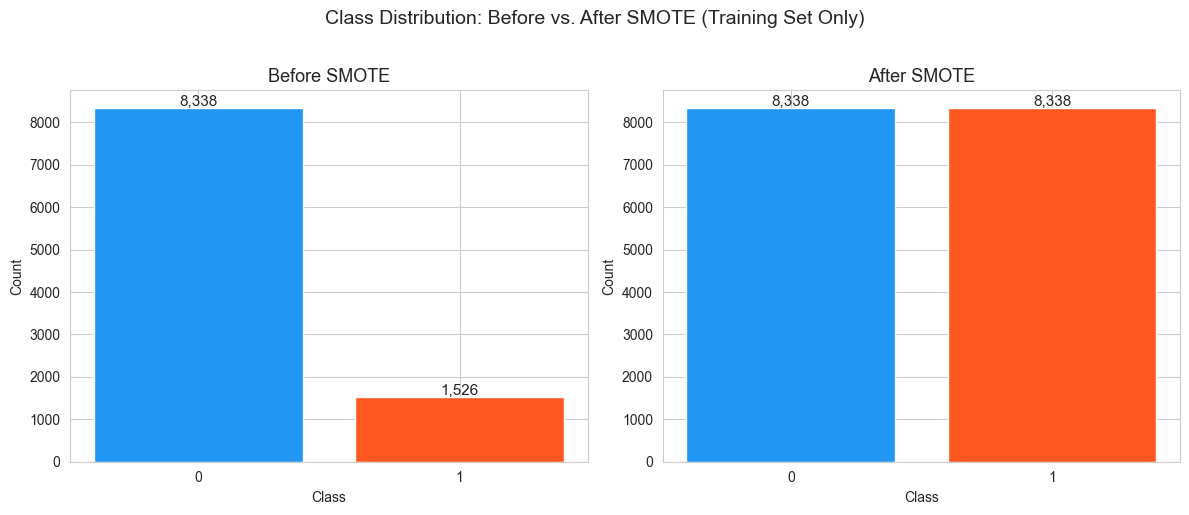

In [8]:
# Visualise before/after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before
u1, c1 = np.unique(y_train, return_counts=True)
axes[0].bar(u1.astype(str), c1, color=['#2196F3', '#FF5722'], edgecolor='white')
axes[0].set_title('Before SMOTE', fontsize=13)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for bar_val, count_val in zip(u1, c1):
    axes[0].text(int(bar_val), count_val + 50, f'{count_val:,}', ha='center', fontsize=11)

# After
u2, c2 = np.unique(y_train_res, return_counts=True)
axes[1].bar(u2.astype(str), c2, color=['#2196F3', '#FF5722'], edgecolor='white')
axes[1].set_title('After SMOTE', fontsize=13)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
for bar_val, count_val in zip(u2, c2):
    axes[1].text(int(bar_val), count_val + 50, f'{count_val:,}', ha='center', fontsize=11)

fig.suptitle('Class Distribution: Before vs. After SMOTE (Training Set Only)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2.4 Save Preprocessed Data

Save the preprocessed arrays so that model notebooks (03–06) can load them directly without re-running the preprocessing pipeline.

In [9]:
save_dir = Path('../data')

# Save arrays
np.savez(
    save_dir / 'preprocessed_data.npz',
    X_train=X_train_res,
    X_test=X_test,
    y_train=y_train_res,
    y_test=y_test,
)

# Save feature names separately
np.save(save_dir / 'feature_names.npy', np.array(feature_names))

print('Preprocessed data saved to:')
print(f'   {save_dir / "preprocessed_data.npz"}')
print(f'   {save_dir / "feature_names.npy"}')

Preprocessed data saved to:
   ../data/preprocessed_data.npz
   ../data/feature_names.npy


## Summary

### Preprocessing Pipeline Recap

| Step | Action | Details |
|------|--------|---------|
| 1 | Feature Encoding | Month (ordinal), VisitorType (label), booleans→int |
| 2 | Train/Test Split | 80/20, stratified, `random_state=42` |
| 3 | Standard Scaling | Fit on train, transform both |
| 4 | SMOTE | Applied to training set **only** |

The preprocessed data is now ready for model training in notebooks 03–05.